<a href="https://colab.research.google.com/github/DMInaam/Vehicle-Detection-and-Classification/blob/main/Vehicle_Detection_and_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Vehicle Detection and Classification System Using Big Data Analytics***
## Project Overview

---



This project implements an intelligent vehicle detection and classification system using deep learning and big data technologies.

The system consists of two main components:

1. Vehicle Detection using YOLOv8
2. Vehicle Classification using EfficientNetB0

Apache Spark is used for large-scale image processing, and the final system is deployed using Streamlit for real-time predictions.

## Objectives

- Detect vehicles in images using YOLOv8
- Classify detected vehicles into categories
- Process large datasets efficiently using Spark
- Deploy the system using Streamlit

## **1. Dataset Setup and Extraction**

---

In this section, Google Drive is mounted to access datasets.
The vehicle detection and classification datasets are downloaded from Zenodo and extracted into the Drive directory for further processing.

In [ ]:
# Mount Drive first
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.1 Downloading Dataset

In [ ]:
import os

rar_path = "/content/drive/MyDrive/VDSet_and_VCSet.rar"

if not os.path.exists(rar_path):

    print("Downloading dataset...")

    !wget -O {rar_path} \
    "https://zenodo.org/records/14792742/files/VDSet_and_VCSet.rar?download=1"

else:

    print("RAR file already exists — skipping download.")

--2026-04-19 15:06:30--  https://zenodo.org/records/14792742/files/VDSet_and_VCSet.rar?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.185.48.75, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4092592108 (3.8G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/VDSet_and_VCSet.rar’

/content/drive/MyDr 100%[===================>]   3.81G  25.3MB/s    in 8m 40s  

2026-04-19 15:15:10 (7.51 MB/s) - ‘/content/drive/MyDrive/VDSet_and_VCSet.rar’ saved [4092592108/4092592108]



In [ ]:
# Install unrar
!apt-get install unrar -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


### 1.2 Extracting Dataset

In [ ]:
import os

# Create dataset folder safely
os.makedirs(
    "/content/drive/MyDrive/datasets",
    exist_ok=True
)

dataset_dir = "/content/drive/MyDrive/datasets/2_Datasets"

# Extract only if not already present
if not os.path.exists(dataset_dir):

    print("Extracting dataset...")

    !unrar x \
    "/content/drive/MyDrive/VDSet_and_VCSet.rar" \
    "/content/drive/MyDrive/datasets/"

else:

    print("Dataset already extracted — skipping.")

Dataset already extracted — skipping.


### 1.3 Dataset Directory Verification

This step verifies that the dataset has been successfully extracted.
The directory structure is printed to confirm that all required folders are available.


In [ ]:
import os

base_path = "/content/drive/MyDrive/datasets"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

print("\nMain folders:\n")
print(os.listdir(base_path))

/content/drive/MyDrive/datasets

Main folders:

['1_Readme.txt', '2_Datasets']


In [ ]:
dataset_path = "/content/drive/MyDrive/datasets/2_Datasets"

print(os.listdir(dataset_path))

['Vehicle Detection Dataset (VDset)', 'Vehicle Classification Dataset (VCset)']


## **2. Apache Spark Setup**

---

Apache Spark is installed and configured to handle large-scale image processing efficiently.
Spark enables distributed data loading and improves performance when working with large datasets.

Spark is used to:

- Load large datasets efficiently
- Process image metadata
- Perform dataset filtering
- Improve scalability

In [ ]:
import os

spark_path = "/content/spark-3.4.1-bin-hadoop3"

# Install Java
print("Installing Java...")
!apt-get install openjdk-11-jdk-headless -qq

# Download Spark only if missing
if not os.path.exists(spark_path):

    print("Downloading Spark...")

    !wget -q \
    https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz

    print("Extracting Spark...")

    !tar -xzf spark-3.4.1-bin-hadoop3.tgz

else:

    print("Spark already available — skipping download.")

# Set environment variables
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = spark_path

# Install findspark
!pip install -q findspark

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Vehicle Big Data Processing") \
    .master("local[*]") \
    .config("spark.driver.memory","12g") \
    .getOrCreate()

print("Spark Started Successfully 🚀")

Installing Java...
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid (rmid) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/pack200 to provide /usr/bin/pack200 (pack200) in auto mode
update-alternatives: usi

#### Copying Dataset to Runtime

---



The dataset is copied from Google Drive to the runtime environment to improve data access speed.

Loading data directly from Google Drive can be slow during training. Copying the dataset to runtime storage reduces latency and significantly improves model training performance.

In [ ]:
import os
import shutil

drive_dataset = "/content/drive/MyDrive/datasets/2_Datasets"

runtime_dataset = "/content/datasets"

if not os.path.exists(drive_dataset):

    raise Exception("Drive dataset not found!")

if not os.path.exists(runtime_dataset):

    print("Copying dataset to runtime (this may take time)...")

    shutil.copytree(
        drive_dataset,
        runtime_dataset
    )

    print("Dataset copied successfully ✅")

else:

    print("Dataset already copied — skipping.")

Copying dataset to runtime (this may take time)...
Dataset copied successfully ✅


### 2.1 Loading Image Dataset Using Spark

In this step, the image dataset is loaded into Spark DataFrame format.
Spark enables parallel processing of images, making it suitable for big data applications.

In [ ]:
from pyspark.sql.functions import col

# Load images from runtime (FAST)
df = spark.read.format("image") \
.load("/content/datasets/Vehicle Detection Dataset (VDset)/images")

print("Total Images Loaded:", df.count())

Total Images Loaded: 8582


In [ ]:
# Cache dataset
df = df.cache()

# Force caching
df.count()

print("Dataset Cached Successfully ✅")

Dataset Cached Successfully ✅


### 2.2 Dataset Filtering

This step filters out images that do not meet size requirements.
Filtering improves dataset quality and ensures consistent model training.

In [ ]:
# Filter images
filtered_df = df.filter(
    col("image.height") > 100
)

print("Filtered Images:", filtered_df.count())

Filtered Images: 4291


## **3. Annotation Conversion to YOLO Format**

---

Vehicle annotations are provided in XML format.
This step converts XML bounding box annotations into YOLO format, which is required for YOLOv8 model training.

YOLO format:
class x_center y_center width height

In [ ]:
import os

base_path = "/content/datasets/Vehicle Detection Dataset (VDset)"

images_dir = os.path.join(base_path, "images")
labels_dir = os.path.join(base_path, "labels")

# Check if labels already exist
txt_files = [f for f in os.listdir(labels_dir) if f.endswith(".txt")]

if len(txt_files) > 0:

    print("YOLO labels already exist — skipping XML conversion ✅")

else:

    print("Converting XML to YOLO format...")

    import xml.etree.ElementTree as ET

    def convert_xml_to_yolo(xml_file):

        tree = ET.parse(xml_file)
        root = tree.getroot()

        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        txt_file = xml_file.replace(".xml", ".txt")

        with open(txt_file, "w") as f:

            for obj in root.findall("object"):

                cls = 0

                xmlbox = obj.find("bndbox")

                xmin = int(xmlbox.find("xmin").text)
                ymin = int(xmlbox.find("ymin").text)
                xmax = int(xmlbox.find("xmax").text)
                ymax = int(xmlbox.find("ymax").text)

                x_center = ((xmin + xmax) / 2) / w
                y_center = ((ymin + ymax) / 2) / h
                width = (xmax - xmin) / w
                height = (ymax - ymin) / h

                f.write(
                    f"{cls} {x_center} {y_center} {width} {height}\n"
                )

    for file in os.listdir(images_dir):

        if file.endswith(".xml"):

            convert_xml_to_yolo(
                os.path.join(images_dir, file)
            )

    print("YOLO conversion completed ✅")

YOLO labels already exist — skipping XML conversion ✅


### 3.1 Organizing Label Files

Converted annotation files are moved into a separate labels directory.
This ensures correct dataset organization for YOLO training.

In [ ]:
import os
import shutil

base_path = "/content/datasets/Vehicle Detection Dataset (VDset)"

images_dir = os.path.join(base_path, "images")
labels_dir = os.path.join(base_path, "labels")

os.makedirs(labels_dir, exist_ok=True)

# Move only if labels folder empty
if len(os.listdir(labels_dir)) == 0:

    print("Moving label files...")

    for file in os.listdir(images_dir):

        if file.endswith(".txt"):

            shutil.move(
                os.path.join(images_dir, file),
                os.path.join(labels_dir, file)
            )

    print("TXT files moved to labels folder ✅")

else:

    print("Labels already organized — skipping.")

Labels already organized — skipping.


### 3.2 Creating Dataset Configuration File

A YAML configuration file is created to define dataset paths and class names.
This file is used by YOLOv8 during model training.

In [ ]:
yaml_path = "/content/vehicle_dataset.yaml"

if os.path.exists(yaml_path):

    print("YAML already exists — skipping creation ✅")

else:

    yaml_content = """

path: /content/datasets/Vehicle Detection Dataset (VDset)

train: images
val: images

names:
  0: vehicle

"""

    with open(yaml_path, "w") as f:
        f.write(yaml_content)

    print("YAML created ✅")

YAML created ✅


## **4. Vehicle Detection Using YOLOv8**

---

YOLOv8 is used to detect vehicles in images.
A pretrained YOLOv8 model is loaded and trained on the custom vehicle detection dataset.


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00



YOLOv8 is trained using the prepared dataset.

Training parameters include:

- Model: YOLOv8 Small
- Image Size: 640x640
- Batch Size: 16
- Epochs: Defined during execution

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="vehicle_dataset.yaml",

    epochs=30,
    imgsz=640,
    batch=16,

    device=0,

    project="/content/drive/MyDrive/yolo_runs",
    name="vehicle_detection",

    save=True,
    save_period=1,

    cache=True,

    patience=10
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vehicle_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9d18767500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

###  4.1 Saving Models

---

The best-performing YOLO model weights are saved to Google Drive for future use and to prevent loss due to runtime disconnection.

In [ ]:
import os
import shutil

# Destination folder
dest_folder = "/content/drive/MyDrive/VDC_Models"

# Create folder if missing
os.makedirs(dest_folder, exist_ok=True)

# Copy best model
shutil.copy(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/weights/best.pt",

"/content/drive/MyDrive/VDC_Models/best_yolo_vehicle.pt"
)

print("Best YOLO model saved to VDC_Models ✅")

Best YOLO model saved to VDC_Models ✅


### 4.2 YOLO Training Results

---



This section visualizes detection performance using:

- Precision-Recall Curve
- Confusion Matrix
- F1 Score Curve
- Loss Graphs

Text(0.5, 1.0, 'YOLO Training Results')

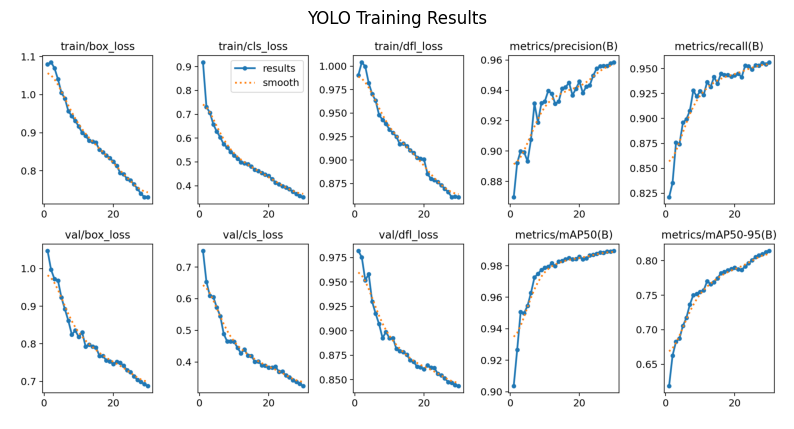

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/results.png"
)

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO Training Results")

### 4.2.1 Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

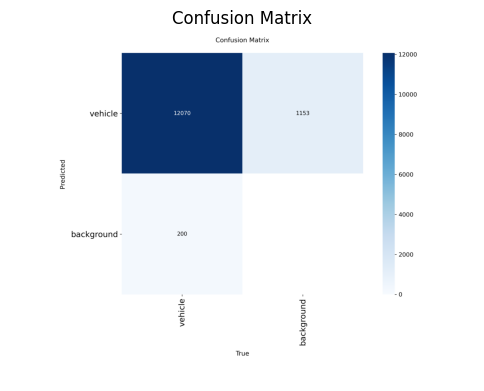

In [ ]:
img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/confusion_matrix.png"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")

### 4.2.2 Normalized Confusion Matrix

Text(0.5, 1.0, 'Normalized Confusion Matrix')

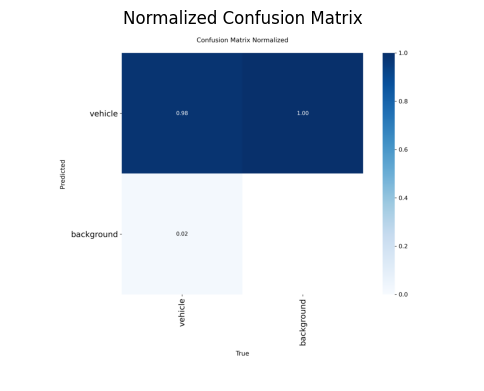

In [ ]:
img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/confusion_matrix_normalized.png"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Normalized Confusion Matrix")

### 4.2.3 Precision–Recall Curve (PR Curve)

Text(0.5, 1.0, 'Precision-Recall Curve')

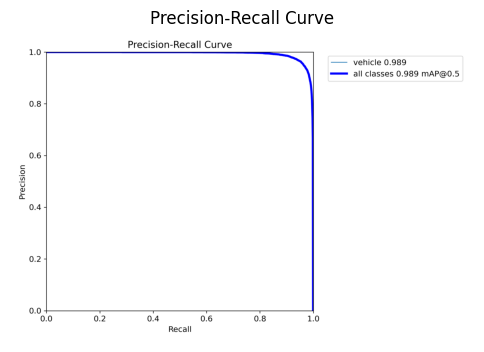

In [ ]:
img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/BoxPR_curve.png"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Precision-Recall Curve")

### 4.2.4 F1 Curve

Text(0.5, 1.0, 'F1 Score Curve')

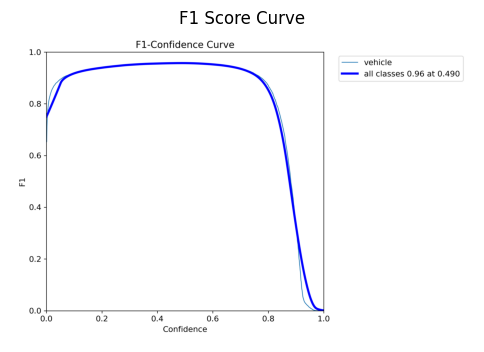

In [ ]:
img = Image.open(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/BoxF1_curve.png"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("F1 Score Curve")

### 4.2.5 Final epoch statistics

In [ ]:
import pandas as pd

df = pd.read_csv(
"/content/drive/MyDrive/yolo_runs/vehicle_detection/results.csv"
)

df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,3454.03,0.76441,0.38582,0.86958,0.95579,0.95321,0.98845,0.80531,0.71364,0.35138,0.85154,0.000350,0.000350,0.000350
26,27,3601.42,0.75275,0.37470,0.86606,0.95609,0.95297,0.98832,0.80763,0.70379,0.34279,0.84742,0.000284,0.000284,0.000284
27,28,3740.56,0.73986,0.36592,0.86067,0.95614,0.95550,0.98902,0.80930,0.69862,0.33727,0.84674,0.000218,0.000218,0.000218
28,29,3887.86,0.73104,0.35766,0.86117,0.95782,0.95436,0.98897,0.81211,0.69234,0.33072,0.84431,0.000152,0.000152,0.000152
29,30,4044.54,0.73047,0.35186,0.86049,0.95852,0.95632,0.98944,0.81406,0.68786,0.32424,0.84357,0.000086,0.000086,0.000086


### 4.2.6 Performance Metrics

In [ ]:
last_row = df.iloc[-1]

print("Precision:", last_row['metrics/precision(B)'])
print("Recall:", last_row['metrics/recall(B)'])
print("mAP50:", last_row['metrics/mAP50(B)'])
print("mAP50-95:", last_row['metrics/mAP50-95(B)'])

Precision: 0.95852
Recall: 0.95632
mAP50: 0.98944
mAP50-95: 0.81406


### 4.2.7 Plot Metrics

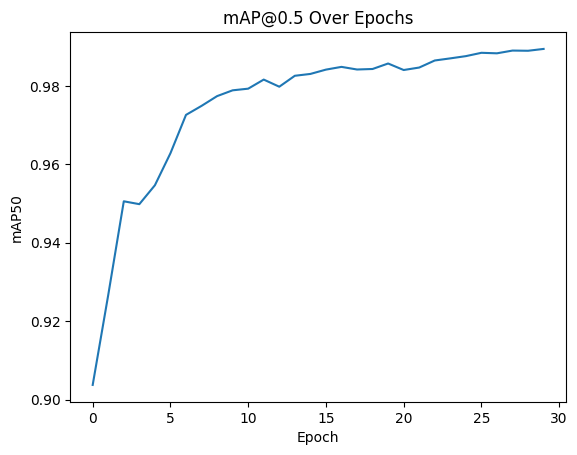

In [ ]:
plt.plot(df['metrics/mAP50(B)'])

plt.title("mAP@0.5 Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")

plt.show()

### 4.2.8 Plot Loss Curves

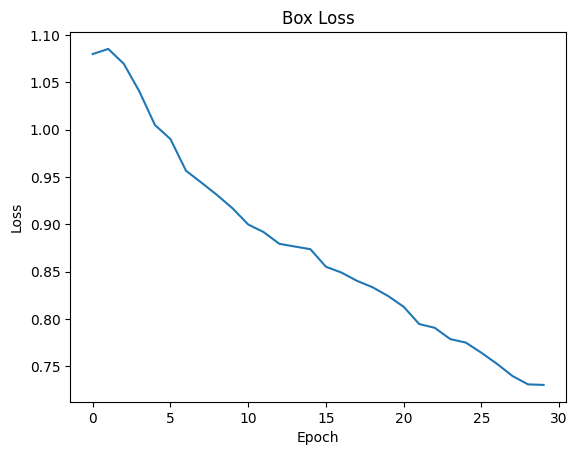

In [ ]:
plt.plot(df['train/box_loss'])

plt.title("Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

## **5. Vehicle Classification Using EfficientNetB0**

---

EfficientNetB0 is used for vehicle classification.
The dataset is prepared using image generators with augmentation to improve model generalization.

In [ ]:
import tensorflow as tf
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Dataset path

dataset_path = "/content/datasets/Vehicle Classification Dataset (VCset)"

# Verify dataset exists
if not os.path.exists(dataset_path):
    raise Exception("Dataset path not found!")

# Image settings

IMG_SIZE = (224,224)

# Safer batch size (recommended)
BATCH_SIZE = 32

# Create model save folders
os.makedirs(
"/content/drive/MyDrive/VDC_Models",
exist_ok=True
)

os.makedirs(
"/content/drive/MyDrive/classification_runs",
exist_ok=True
)

print("Setup completed ✅")

Setup completed ✅


### 5.1 Data Augmentation

Data augmentation techniques such as rotation, zoom, flipping, and brightness adjustment are applied to increase dataset diversity and prevent overfitting.

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,        # slightly reduced
    zoom_range=0.2,           # safer
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],   # safer brightness
    validation_split=0.2,
    fill_mode="nearest"
)

print("Data augmentation ready ✅")

Data augmentation ready ✅


In [ ]:
# Training generator

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True,      # important for good training
    seed=42            # ensures same split every run
)

print("Training generator ready ✅")

Found 8000 images belonging to 5 classes.
Training generator ready ✅


In [ ]:
# Validation generator

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False,   # important for validation
    seed=42          # must match training generator
)

print("Validation generator ready ✅")

Found 2000 images belonging to 5 classes.
Validation generator ready ✅


In [ ]:
print("Class Indices Mapping:")

print(train_generator.class_indices)

# Save class indices (very important for prediction later)

import json

class_indices = train_generator.class_indices

with open(
"/content/drive/MyDrive/VDC_Models/class_indices.json",
"w"
) as f:

    json.dump(class_indices, f)

print("Class indices saved to Drive ✅")

Class Indices Mapping:
{'bus': 0, 'car': 1, 'motorcycle': 2, 'truck': 3, 'van': 4}
Class indices saved to Drive ✅


### 5.2 Model Architecture Construction

EfficientNetB0 is used as the base model with pretrained ImageNet weights.
Custom dense layers are added for vehicle classification into five categories.

In [ ]:
# 🔥 Load EfficientNetB0

base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

print("EfficientNetB0 loaded successfully ✅")

# Show architecture summary
base_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded successfully ✅


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
# Freeze base model first

base_model.trainable = False

# Get number of classes automatically
num_classes = train_generator.num_classes

# 🔥 Build Model

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

print("Classification model built successfully ✅")

# Show architecture
model.summary()

Classification model built successfully ✅


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,168 (16.85 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
print("Number of classes:", train_generator.num_classes)

Number of classes: 5


### 5.3 Model Compilation

The model is compiled using the Adam optimizer and sparse categorical crossentropy loss function.
Accuracy is used as the evaluation metric.

In [ ]:
# Compile model

model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully ✅")

model.summary()

Model compiled successfully ✅


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,168 (16.85 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# Create folders (if not exists)

import os

os.makedirs(
"/content/drive/MyDrive/VDC_Models",
exist_ok=True
)

os.makedirs(
"/content/drive/MyDrive/classification_runs",
exist_ok=True
)

In [ ]:
# Callbacks

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Save BEST model

best_checkpoint = ModelCheckpoint(
"/content/drive/MyDrive/VDC_Models/vehicle_classifier_best.keras",
monitor='val_accuracy',
save_best_only=True,
verbose=1
)

In [ ]:
# Save EVERY epoch

epoch_checkpoint = ModelCheckpoint(
filepath="/content/drive/MyDrive/classification_runs/efficientnet_epoch_{epoch:02d}.keras",
save_best_only=False,
verbose=1
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("ReduceLROnPlateau ready ✅")

ReduceLROnPlateau ready ✅


### 5.4 Phase 1 Training

In Phase 1, the base model layers are frozen and only the top classification layers are trained.
This allows the model to learn dataset-specific features.

In [ ]:
# 🔥 Phase 1 Training

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        early_stop,
        best_checkpoint,     # saves best model
        epoch_checkpoint,    # saves every epoch
        reduce_lr
    ]
)

print("EfficientNet Phase 1 Completed ✅")

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.5244 - loss: 1.2920
Epoch 1: val_accuracy improved from None to 0.79050, saving model to /content/drive/MyDrive/VDC_Models/vehicle_classifier_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/VDC_Models/vehicle_classifier_best.keras

Epoch 1: saving model to /content/drive/MyDrive/classification_runs/efficientnet_epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/classification_runs/efficientnet_epoch_01.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 198s 658ms/step - accuracy: 0.6319 - loss: 0.9939 - val_accuracy: 0.7905 - val_loss: 0.6106 - learning_rate: 3.0000e-04
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.7457 - loss: 0.6622
Epoch 2: val_accuracy improved from 0.79050 to 0.83550, saving model to /content/drive/MyDrive/VDC_Models/vehicle_classifier_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/VDC_Models/vehicle_classifier_best.keras

Epoc

In [ ]:
# Save Phase 1 history

import pickle

with open(
"/content/drive/MyDrive/VDC_Models/history_phase1.pkl",
"wb"
) as f:

    pickle.dump(history.history, f)

print("Phase 1 history saved ✅")

Phase 1 history saved ✅


### 5.5 Fine-Tuning the Model

Fine-tuning involves unfreezing selected layers of the base model.
This improves model performance by refining learned features.

In [ ]:
base_model = model.layers[0]

for layer in base_model.layers[-60:]:

    # Keep BatchNorm frozen
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks for Fine-Tuning

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau


# Early stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# Save BEST model

checkpoint = ModelCheckpoint(
"/content/drive/MyDrive/VDC_Models/vehicle_classifier_efficientnet_finetuned.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
# Save EVERY epoch
epoch_checkpoint = ModelCheckpoint(
"/content/drive/MyDrive/classification_runs/efficientnet_finetune_epoch_{epoch:02d}.keras",
    save_freq='epoch',
    verbose=1
)

In [ ]:
# Reduce learning rate automatically

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,168 (16.85 MB)

 Trainable params: 3,013,317 (11.49 MB)

 Non-trainable params: 1,402,851 (5.35 MB)

In [ ]:
# Fine-Tuning Training

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    callbacks=[
        early_stop,
        checkpoint,
        epoch_checkpoint,
        reduce_lr
    ]
)

print("Fine-Tuning Completed ✅")

Epoch 1/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.9178 - loss: 0.2204
Epoch 1: val_accuracy improved from None to 0.93100, saving model to /content/drive/MyDrive/VDC_Models/vehicle_classifier_efficientnet_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/VDC_Models/vehicle_classifier_efficientnet_finetuned.keras

Epoch 1: saving model to /content/drive/MyDrive/classification_runs/efficientnet_finetune_epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/classification_runs/efficientnet_finetune_epoch_01.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 201s 672ms/step - accuracy: 0.9211 - loss: 0.2178 - val_accuracy: 0.9310 - val_loss: 0.2033 - learning_rate: 1.0000e-05
Epoch 2/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9282 - loss: 0.1911
Epoch 2: val_accuracy did not improve from 0.93100

Epoch 2: saving model to /content/drive/MyDrive/classification_runs/efficientnet_finetune_epoch_02.keras

Epoch 2: finished saving model

In [ ]:
# 🔥 Save Final Model

model.save(
"/content/drive/MyDrive/VDC_Models/vehicle_classifier_efficientnet_final.keras"
)

print("Final Model Saved ✅")

Final Model Saved ✅


In [ ]:
# Save Fine-Tuning History

import pickle

with open(
"/content/drive/MyDrive/VDC_Models/history_finetune.pkl",
"wb"
) as f:
    pickle.dump(history_fine.history, f)

print("Fine-tuning history saved ✅")

Fine-tuning history saved ✅


## 5.6 Classification Evaluation

---



Model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

### 5.6.1 Loading Training History

---

The saved training history of Phase 1 and fine-tuned models is loaded to analyze and visualize training performance metrics such as accuracy and loss.

In [ ]:
import pickle

# Load Phase-1 history
with open(
"/content/drive/MyDrive/VDC_Models/history_phase1.pkl",
"rb"
) as f:
    history_phase1 = pickle.load(f)


# Load Fine-Tuning history
with open(
"/content/drive/MyDrive/VDC_Models/history_finetune.pkl",
"rb"
) as f:
    history_finetune = pickle.load(f)

print("Histories loaded successfully ✅")

Histories loaded successfully ✅


### 5.6.2 Training and Validation Accuracy

---

This section visualizes the training and validation accuracy curves for both Phase 1 and fine-tuned models. These plots help evaluate how well the model learns over time and identify improvements after fine-tuning.

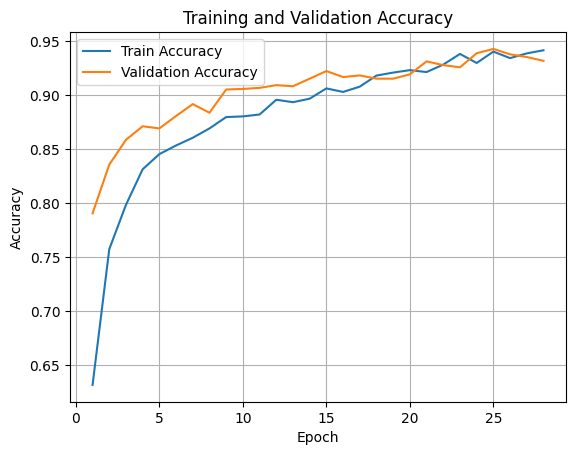

In [ ]:
import matplotlib.pyplot as plt

# Combine histories

train_acc = (
    history_phase1['accuracy']
    + history_finetune['accuracy']
)

val_acc = (
    history_phase1['val_accuracy']
    + history_finetune['val_accuracy']
)

train_loss = (
    history_phase1['loss']
    + history_finetune['loss']
)

val_loss = (
    history_phase1['val_loss']
    + history_finetune['val_loss']
)

epochs = range(1, len(train_acc) + 1)

# Accuracy Plot
plt.figure()
plt.plot(epochs, train_acc)
plt.plot(epochs, val_acc)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.grid()
plt.savefig(
"/content/drive/MyDrive/VDC_Models/accuracy_curve.png"
)
plt.show()

### 5.6.3 Training and Validation Loss

---

This section visualizes the training and validation loss curves for both Phase 1 and fine-tuned models. These plots help monitor the model's learning process and identify whether the model is improving or overfitting during training.

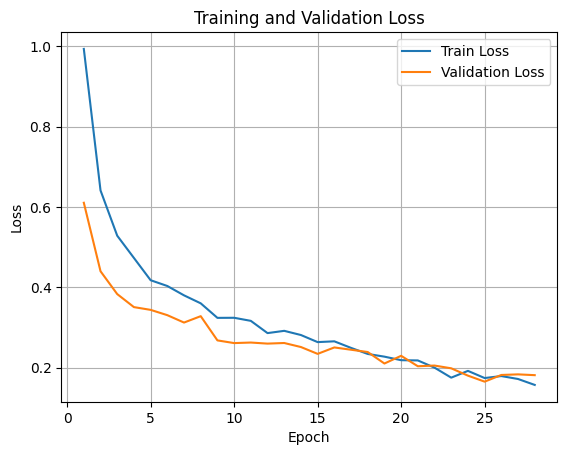

In [ ]:
# Loss Plot
plt.figure()
plt.plot(epochs, train_loss)
plt.plot(epochs, val_loss)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.grid()
plt.savefig(
"/content/drive/MyDrive/VDC_Models/loss_curve.png"
)
plt.show()

### 5.6.4 Phase 1 and Fine-Tuned Model Accuracy Comparison
---
This section compares the validation accuracy of the Phase 1 model and the fine-tuned model. The comparison helps evaluate the improvement achieved after fine-tuning the EfficientNet model.

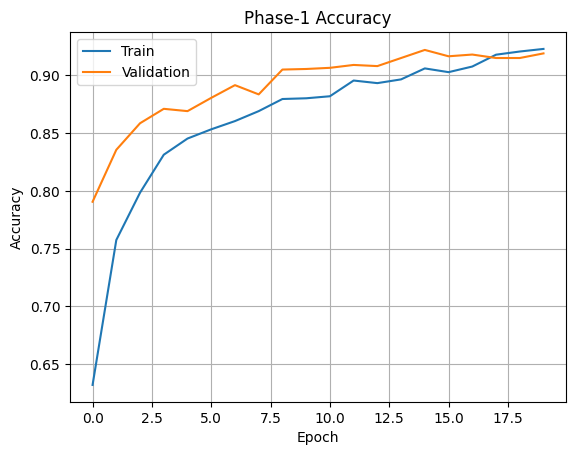

In [ ]:
# Phase-1 Accuracy
plt.figure()
plt.plot(history_phase1['accuracy'])
plt.plot(history_phase1['val_accuracy'])
plt.title("Phase-1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid()
plt.savefig(
"/content/drive/MyDrive/VDC_Models/phase1_accuracy.png"
)
plt.show()


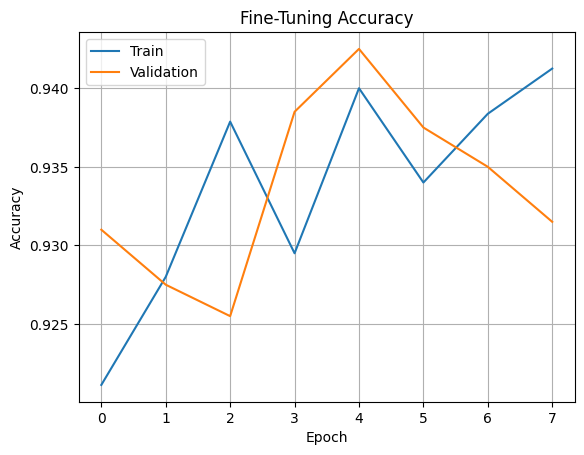

In [ ]:
# Fine-Tuning Accuracy
plt.figure()
plt.plot(history_finetune['accuracy'])
plt.plot(history_finetune['val_accuracy'])
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid()
plt.savefig(
"/content/drive/MyDrive/VDC_Models/finetune_accuracy.png"
)
plt.show()

### 5.6.5 Final Model Performance

---

This section presents the final performance of the trained classification model using evaluation metrics such as accuracy, precision, recall, and F1-score. These metrics provide an overall assessment of the model's effectiveness on unseen validation data.

In [ ]:
# Combine validation accuracy

val_acc_combined = (
    history_phase1['val_accuracy']
    + history_finetune['val_accuracy']
)

train_acc_combined = (
    history_phase1['accuracy']
    + history_finetune['accuracy']
)

train_loss_combined = (
    history_phase1['loss']
    + history_finetune['loss']
)

val_loss_combined = (
    history_phase1['val_loss']
    + history_finetune['val_loss']
)


# Calculate statistics

best_val_acc = max(val_acc_combined)
best_epoch = (val_acc_combined.index(best_val_acc) + 1)

final_train_acc = train_acc_combined[-1]
final_val_acc = val_acc_combined[-1]

final_train_loss = train_loss_combined[-1]
final_val_loss = val_loss_combined[-1]


print("===== FINAL MODEL PERFORMANCE =====")

print(f"Best Validation Accuracy : {best_val_acc:.4f}")
print(f"Best Epoch              : {best_epoch}")

print(f"Final Training Accuracy : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")

print(f"Final Training Loss : {final_train_loss:.4f}")
print(f"Final Validation Loss : {final_val_loss:.4f}")

===== FINAL MODEL PERFORMANCE =====
Best Validation Accuracy : 0.9425
Best Epoch              : 25
Final Training Accuracy : 0.9413
Final Validation Accuracy : 0.9315
Final Training Loss : 0.1568
Final Validation Loss : 0.1811


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
"/content/drive/MyDrive/VDC_Models/vehicle_classifier_efficientnet_final.keras"
)

print("Model Loaded Successfully ✅")

Model Loaded Successfully ✅


In [ ]:
import os
import shutil

drive_dataset = "/content/drive/MyDrive/datasets/2_Datasets/Vehicle Classification Dataset (VCset)"

runtime_dataset = "/content/VCset"

if not os.path.exists(drive_dataset):

    raise Exception("Drive dataset not found!")

if not os.path.exists(runtime_dataset):

    print("Copying dataset to runtime (this may take time)...")

    shutil.copytree(
        drive_dataset,
        runtime_dataset
    )

    print("Dataset copied successfully ✅")

else:

    print("Dataset already copied — skipping.")

Copying dataset to runtime (this may take time)...
Dataset copied successfully ✅


### 5.6.6 Model Predictions

---

The trained model is used to generate predictions on the validation dataset. These predictions are later used to compute evaluation metrics such as the confusion matrix and classification report.

The validation dataset is loaded using an ImageDataGenerator with EfficientNet preprocessing.
The data is prepared without shuffling to ensure consistent evaluation and accurate performance measurement of the final model.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

dataset_path = "/content/VCset"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.2
)

validation_generator = test_datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='sparse',

    subset='validation',

    shuffle=False
)

print("Validation dataset loaded ✅")
print("Steps:", validation_generator.samples // BATCH_SIZE)

Found 2000 images belonging to 5 classes.
Validation dataset loaded ✅
Steps: 62


In [ ]:
import numpy as np

predictions = model.predict(
    validation_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)

y_true = validation_generator.classes

print("Predictions completed ✅")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1452s 23s/step
Predictions completed ✅


### 5.6.7 Confusion Matrix

---

A confusion matrix is plotted to evaluate the classification performance of the model across all vehicle classes. It helps analyze prediction accuracy by showing the relationship between actual and predicted labels, and highlights areas where misclassification occurs.

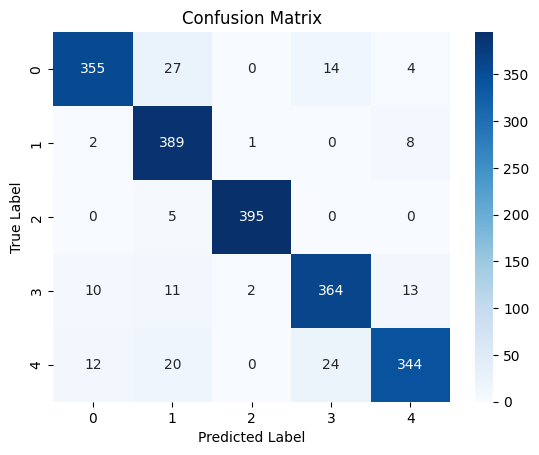

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig(
"/content/drive/MyDrive/VDC_Models/confusion_matrix_efficientNet.png"
)
plt.show()

### 5.6.8 Classification Report

---

A classification report is generated to evaluate the model's performance across all vehicle classes. It includes precision, recall, F1-score, and overall accuracy, providing a detailed understanding of the model's classification effectiveness.

In [ ]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

         bus       0.94      0.89      0.91       400
         car       0.86      0.97      0.91       400
  motorcycle       0.99      0.99      0.99       400
       truck       0.91      0.91      0.91       400
         van       0.93      0.86      0.89       400

    accuracy                           0.92      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.93      0.92      0.92      2000



### 5.6.9 Sample Prediction Visualization

---

Sample validation images are displayed along with their predicted and actual labels. This visualization helps assess the model's real-world performance and visually identify correct predictions and misclassifications.

These examples demonstrate the model's practical prediction capability on real validation images.

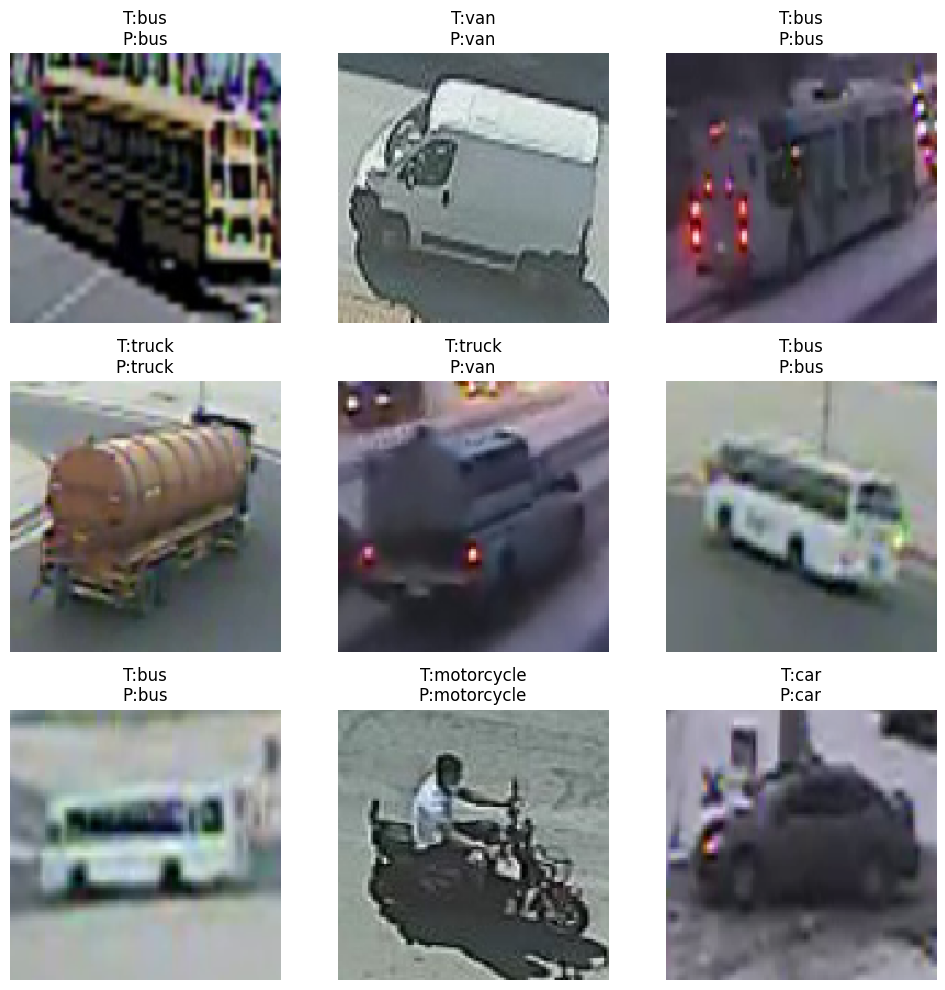

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

class_labels = list(validation_generator.class_indices.keys())

plt.figure(figsize=(10,10))
for i in range(9):
    batch_index = random.randint(
        0,
        len(validation_generator)-1
    )
    images, labels = validation_generator[batch_index]
    img_index = random.randint(
        0,
        len(images)-1
    )
    img = images[img_index]
    # 🔥 Fix display scaling
    img = img.astype("float32")
    img = (img - img.min()) / (img.max() - img.min())
    true_label = class_labels[
        int(labels[img_index])
    ]
    pred_label = class_labels[
        y_pred[
            batch_index * validation_generator.batch_size
            + img_index
        ]
    ]
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"T:{true_label}\nP:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## **6. Deployment Using Streamlit**

---

A Streamlit web application is created to allow users to upload images and detect vehicles in real time.
YOLO detects vehicles, and EfficientNet classifies them.

In [ ]:
!pip install streamlit ultralytics tensorflow opencv-python pillow pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.9 MB/s eta 0:00:00


In [ ]:
%%writefile streamlit_app.py

import streamlit as st
import numpy as np
import cv2
import tensorflow as tf
from ultralytics import YOLO
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

# Page Config
st.set_page_config(
    page_title="Vehicle Detection System",
    layout="wide"
)

# Sidebar
st.sidebar.title("⚙️ Controls")
conf_threshold = st.sidebar.slider(
    "YOLO Confidence",
    0.1,
    0.9,
    0.45
)
st.sidebar.markdown("---")
st.sidebar.write("### Model Info")
st.sidebar.info(
"""
YOLOv8 — Detection
EfficientNetB0 — Classification

Classes:
- Bus
- Car
- Motorcycle
- Truck
- Van
"""
)

# Load Models
@st.cache_resource
def load_models():
    yolo_model = YOLO(
        "/content/drive/MyDrive/VDC_Models/best_yolo_vehicle.pt"
    )
    classifier_model = tf.keras.models.load_model(
        "/content/drive/MyDrive/VDC_Models/vehicle_classifier_efficientnet_final.keras"
    )
    return yolo_model, classifier_model

yolo_model, classifier_model = load_models()

class_names = [
    'bus',
    'car',
    'motorcycle',
    'truck',
    'van'
]

# Title
st.markdown(
"""
<h1 style='text-align:center;
color:#4CAF50;'>
Vehicle Detection and Classification System
</h1>
""",
unsafe_allow_html=True
)

uploaded_file = st.file_uploader(
    "Upload Vehicle Image",
    type=["jpg", "jpeg", "png", "webp", "bmp"]
)

# =============================
# MAIN PROCESS
# =============================

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    img = np.array(image)

    # Resize large images
    if img.shape[1] > 1280:
        img = cv2.resize(
            img,
            (1280, 720)
        )

    # Layout for original and detected image
    col1, col2 = st.columns([1,1])
    with col1:
        st.image(
            image,
            caption="Uploaded Image",
            width="stretch"
        )

    # Detection
    with st.spinner("Detecting vehicles..."):
        results = yolo_model(
            img,
            imgsz=640,
            conf=conf_threshold,
            iou=0.45
        )

    annotated_img = results[0].plot()
    with col2:
        st.image(
            annotated_img,
            caption="Detected Vehicles",
            width="stretch"
        )

    boxes = results[0].boxes

    # =============================
    # MULTI-VEHICLE CLASSIFICATION
    # =============================

    if boxes is not None and len(boxes) > 0:
        total_vehicles = len(boxes)
        st.markdown("---")
        st.subheader("🔍 Vehicle Classification Results")
        st.info(
            f"🚗 Detected Vehicles: {total_vehicles}"
        )

        # Loop through all detected vehicles
        for i, box in enumerate(boxes):
            st.markdown("---")

            # Create 2-column layout
            col_img, col_info = st.columns([1,2])

            # Get bounding box
            h, w, _ = img.shape
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Clamp values inside image
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)

            crop = img[y1:y2, x1:x2]

            if crop.size > 0 and crop.shape[0] > 10 and crop.shape[1] > 10:
                # Resize for classifier
                crop_resized = cv2.resize(
                    crop,
                    (224,224)
                )
                crop_input = preprocess_input(
                    crop_resized
                )
                crop_input = np.expand_dims(
                    crop_input,
                    axis=0
                )

                # Predict
                prediction = classifier_model.predict(
                    crop_input,
                    verbose=0
                )
                predicted_class = class_names[
                    np.argmax(prediction)
                ]
                confidence = float(
                    np.max(prediction)
                )
                yolo_conf = float(box.conf.item())

                # Show small image
                with col_img:
                    display_crop = cv2.resize(
                        crop,
                        (180,180),
                        interpolation=cv2.INTER_CUBIC
                    )
                    st.image(
                        display_crop,
                        caption=f"Vehicle {i+1}",
                        width=180
                    )

                emoji_map = {
                    "car": "🚗",
                    "bus": "🚌",
                    "truck": "🚛",
                    "motorcycle": "🏍️",
                    "van": "🚐"
                }

                # Show result
                with col_info:
                    icon = emoji_map.get(predicted_class, "🚗")

                    # st.success(
                    #     f"{icon} Vehicle {i+1}: {predicted_class.upper()}"
                    # )
                    st.markdown(
                      f"""
                      <div style="
                      background-color:#1b5e20;
                      padding:12px;
                      border-radius:8px;
                      color:white;
                      font-weight:bold;
                      ">
                      {icon} Vehicle {i+1}: {predicted_class.upper()}
                      </div>
                      """,
                      unsafe_allow_html=True
                    )

                    st.progress(confidence)
                    st.caption(
                        f"YOLO Confidence: {yolo_conf:.2f}"
                    )
                    st.caption(
                        f"Confidence Score: {confidence:.2f}"
                    )

    else:

        st.warning("No vehicle detected.")

Writing streamlit_app.py


### 6.1 Public Deployment Using Ngrok

---

Ngrok is used to create a secure public URL that allows external access to the locally hosted Streamlit application.

In [ ]:
!pip install pyngrok

In [ ]:
from google.colab import userdata
from pyngrok import ngrok

# Get token from secrets
token = userdata.get("NGROK_TOKEN")

# Set auth token
ngrok.set_auth_token(token)

print("✅ NGROK token loaded successfully")

✅ NGROK token loaded successfully


In [ ]:
from pyngrok import ngrok
import os

# Stop old tunnels
ngrok.kill()

# Start Streamlit
get_ipython().system_raw(
    'streamlit run streamlit_app.py --server.port 8501 &'
)

# Create public link
public_url = ngrok.connect(8501)

print("Your Streamlit App URL:")
print(public_url)

Your Streamlit App URL:
NgrokTunnel: "https://plant-arrogant-deflector.ngrok-free.dev" -> "http://localhost:8501"


## **7. Conclusion**

In this project, a complete vehicle detection and classification system was successfully developed using deep learning techniques. The YOLOv8 model was used for vehicle detection, while EfficientNetB0 was applied for vehicle type classification.

The detection model achieved high performance with strong precision and recall values, demonstrating reliable localization of vehicles in images. The classification model achieved an overall accuracy of approximately 92% across five vehicle categories: bus, car, motorcycle, truck, and van.

Fine-tuning the EfficientNet model significantly improved classification performance and enhanced the model's ability to distinguish between visually similar vehicle types. The combined detection and classification pipeline provides accurate and efficient results suitable for real-world intelligent transportation and surveillance applications.

Overall, the project demonstrates the effectiveness of transfer learning and deep learning-based object detection techniques in solving practical computer vision problems.

### Final Performance Summary

---

### Vehicle Detection (YOLOv8)

- **Precision:** 0.9585  
- **Recall:** 0.9563  
- **mAP@0.5:** 0.9894  
- **mAP@0.5–0.95:** 0.8140  
- **Model:** YOLOv8s  

### Vehicle Classification (EfficientNetB0)

- **Total Classes:** 5  
- **Best Validation Accuracy:** 94.25%  
- **Final Accuracy:** 92%  
- **Macro F1-score:** 0.92  
- **Weighted F1-score:** 0.92  

## **8. Future Work**

---

Future improvements to this project may include:

- Real-time video-based vehicle detection
- Multi-object tracking across frames
- Vehicle counting and traffic analytics
- Speed estimation of moving vehicles
- Deployment on edge devices such as Raspberry Pi or Jetson Nano